In [15]:
!wget --no-check-certificate \
    https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip \
    -O /content/Data/cats_and_dogs_filtered.zip

--2023-08-11 03:11:06--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.202.128, 74.125.69.128, 64.233.181.128, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.202.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/content/Data/cats_and_dogs_filtered.zip’

/content/Data/cats_ 100%[===================>]  65.43M   192MB/s    in 0.3s    

2023-08-11 03:11:06 (192 MB/s) - ‘/content/Data/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



In [16]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
# unzipping the file
local_zip = '/content/Data/cats_and_dogs_filtered.zip'
zipref = zipfile.ZipFile(local_zip, 'r')
zipref.extractall('/content/Data')

In [18]:
os.listdir('/content/Data/cats_and_dogs_filtered')

['vectorize.py', 'train', 'validation']

In [19]:
print(os.listdir('/content/Data/cats_and_dogs_filtered/train'))
print(os.listdir('/content/Data/cats_and_dogs_filtered/validation'))

['dogs', 'cats']
['dogs', 'cats']


In [20]:
base_dir  = '/content/Data/cats_and_dogs_filtered'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'validation')

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
val_cats_dir   = os.path.join(val_dir, 'cats')
val_dogs_dir   = os.path.join(val_dir, 'dogs')

print(train_cats_dir, train_dogs_dir, val_cats_dir, val_dogs_dir, sep = '\n')

/content/Data/cats_and_dogs_filtered/train/cats
/content/Data/cats_and_dogs_filtered/train/dogs
/content/Data/cats_and_dogs_filtered/validation/cats
/content/Data/cats_and_dogs_filtered/validation/dogs


In [21]:
print(os.listdir(train_cats_dir)[:5])
print(os.listdir(train_dogs_dir)[:5])

['cat.341.jpg', 'cat.188.jpg', 'cat.267.jpg', 'cat.255.jpg', 'cat.657.jpg']
['dog.587.jpg', 'dog.228.jpg', 'dog.201.jpg', 'dog.475.jpg', 'dog.181.jpg']


In [22]:
print('Number of training cat images   : ', len(os.listdir(train_cats_dir)))
print('Number of training dog images   : ', len(os.listdir(train_dogs_dir)))
print('Number of validation cat images : ', len(os.listdir(val_cats_dir)))
print('Number of validation dog images : ', len(os.listdir(val_dogs_dir)))

Number of training cat images   :  1000
Number of training dog images   :  1000
Number of validation cat images :  500
Number of validation dog images :  500


(315, 467, 3)


(-0.5, 466.5, 314.5, -0.5)

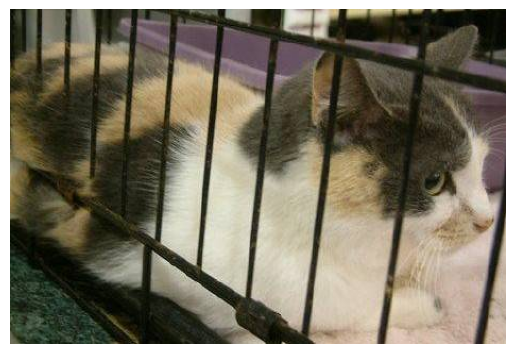

In [27]:
# accessing and visualizing a cat image
cat_image_path = os.path.join(train_cats_dir, 'cat.657.jpg')
cat_image = mpimg.imread(cat_image_path)
print(cat_image.shape)
plt.imshow(cat_image)
plt.axis('off')

(290, 259, 3)


(-0.5, 258.5, 289.5, -0.5)

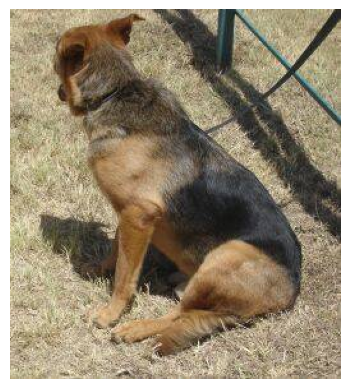

In [29]:
# accessing and visualizing a dog image
dog_image_path = os.path.join(train_dogs_dir, 'dog.587.jpg')
dog_image = mpimg.imread(dog_image_path)
print(dog_image.shape)
plt.imshow(dog_image)
plt.axis('off')

In [36]:
cat_images = os.listdir(train_cats_dir)[:45]
dog_images = os.listdir(train_dogs_dir)[:45]

cat_image_paths = [os.path.join(train_cats_dir, image) for image in cat_images]
dog_image_paths = [os.path.join(train_dogs_dir, image) for image in dog_images]

image_paths = cat_image_paths + dog_image_paths

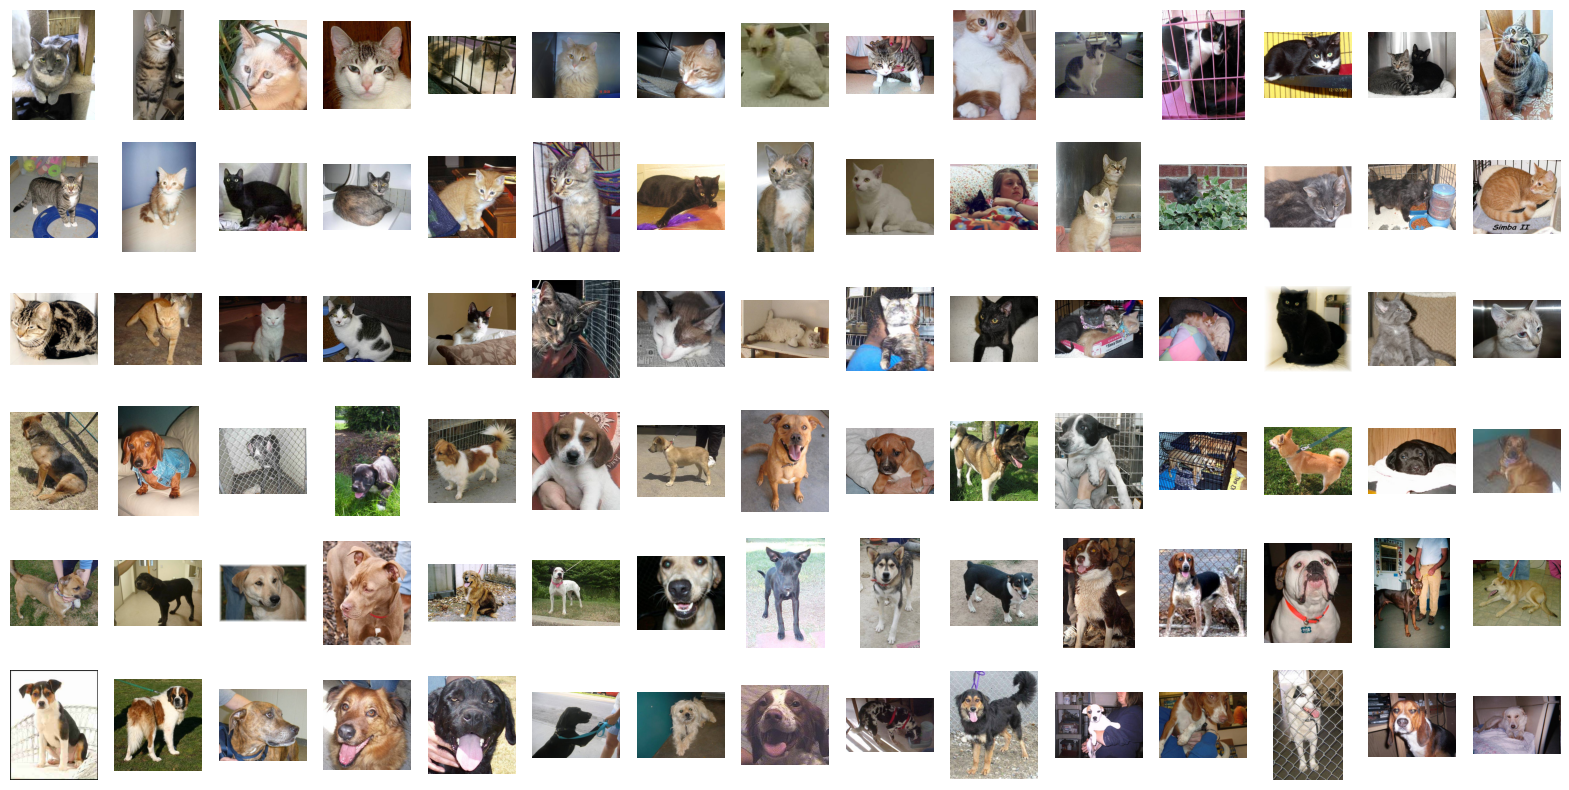

In [37]:
plt.figure(figsize = (20,10))
for i in range(90):
  plt.subplot(6, 15, i+1)
  plt.axis('off')
  image = mpimg.imread(image_paths[i])
  plt.imshow(image)